# Performance Analytics

This notebook computes advanced mutual fund performance metrics including:

- CAGR
- Annualized Volatility
- Sharpe Ratio
- Sortino Ratio
- Beta
- Alpha
- Maximum Drawdown
- Value at Risk (VaR)

Objective:
- Compare mutual fund performance
- Measure risk-adjusted returns
- Evaluate downside risk
- Identify top-performing funds

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
performance = pd.read_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\07_scheme_performance.csv"
)

nav_history = pd.read_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\02_nav_history.csv"
)

benchmark = pd.read_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\raw\10_benchmark_indices.csv"
)

In [3]:
print(performance.shape)
print(nav_history.shape)
print(benchmark.shape)

(40, 19)
(46000, 3)
(8050, 3)


In [4]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [5]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [6]:
benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [7]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


## CAGR Calculation

In [8]:
def calculate_cagr(nav_series):

    start_nav = nav_series.iloc[0]
    end_nav = nav_series.iloc[-1]

    years = len(nav_series) / 252

    return (
        (end_nav / start_nav) ** (1 / years) - 1
    ) * 100

In [9]:
def calculate_volatility(return_series):

    return (
        return_series.std()
        * np.sqrt(252)
        * 100
    )

In [10]:
def calculate_sharpe_ratio(
    cagr,
    volatility,
    risk_free_rate=6
):

    return (
        cagr - risk_free_rate
    ) / volatility

In [11]:
def calculate_max_drawdown(nav_series):

    running_max = nav_series.cummax()

    drawdown = (
        nav_series - running_max
    ) / running_max

    return drawdown.min() * 100

In [12]:
metrics = []

for amfi_code, group in nav_history.groupby("amfi_code"):

    nav_series = group["nav"].dropna()

    returns = group["daily_return"].dropna()

    if len(nav_series) < 30:
        continue

    cagr = calculate_cagr(nav_series)

    volatility = calculate_volatility(
        returns
    )

    sharpe = calculate_sharpe_ratio(
        cagr,
        volatility
    )

    max_dd = calculate_max_drawdown(
        nav_series
    )

    metrics.append(
        [
            amfi_code,
            cagr,
            volatility,
            sharpe,
            max_dd
        ]
    )

metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "amfi_code",
        "cagr",
        "volatility",
        "sharpe_ratio",
        "max_drawdown"
    ]
)

metrics_df.head()

,amfi_code,cagr,volatility,sharpe_ratio,max_drawdown
0,100016,2.541248,14.548135,-0.237745,-24.734441
1,100025,4.294835,3.905246,-0.436634,-4.308264
2,100033,28.899384,18.936711,1.209259,-16.217209
3,101206,22.604787,14.568213,1.139796,-11.291596
4,101207,7.643258,25.797322,0.063699,-35.446916


In [13]:
def calculate_sortino_ratio(
    returns,
    cagr,
    risk_free_rate=6
):

    downside_returns = returns[
        returns < 0
    ]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
        * 100
    )

    if downside_std == 0:
        return np.nan

    return (
        cagr - risk_free_rate
    ) / downside_std

In [14]:
metrics_df["sortino_ratio"] = np.nan

for i, amfi_code in enumerate(
    metrics_df["amfi_code"]
):

    fund_returns = nav_history[
        nav_history["amfi_code"] == amfi_code
    ]["daily_return"].dropna()

    metrics_df.loc[
        i,
        "sortino_ratio"
    ] = calculate_sortino_ratio(
        fund_returns,
        metrics_df.loc[i, "cagr"]
    )

metrics_df.head()

,amfi_code,cagr,volatility,sharpe_ratio,max_drawdown,sortino_ratio
0,100016,2.541248,14.548135,-0.237745,-24.734441,-0.414158
1,100025,4.294835,3.905246,-0.436634,-4.308264,-0.725155
2,100033,28.899384,18.936711,1.209259,-16.217209,2.022400
3,101206,22.604787,14.568213,1.139796,-11.291596,1.996795
4,101207,7.643258,25.797322,0.063699,-35.446916,0.108335


## Top Funds by Risk Adjusted Returns

In [15]:
top_sharpe = (
    metrics_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

top_sharpe

,amfi_code,cagr,volatility,sharpe_ratio,max_drawdown,sortino_ratio
27,120507,6.968970,0.493913,1.961824,-0.097731,4.163777
34,148567,29.711990,14.193707,1.670599,-11.265729,2.751832
30,120843,29.648348,15.886987,1.488536,-12.973968,2.693240
36,148569,30.643215,17.674007,1.394320,-16.396743,2.424011
19,119551,24.772562,13.741434,1.366128,-15.012385,2.419896
25,120505,31.481115,19.290949,1.320884,-18.188514,2.271450
31,120844,6.659029,0.513317,1.283864,-0.116293,2.715698
38,149323,28.381646,17.746159,1.261211,-17.248106,2.088907
2,100033,28.899384,18.936711,1.209259,-16.217209,2.022400
9,118632,23.093816,14.148352,1.208184,-17.414075,2.066548


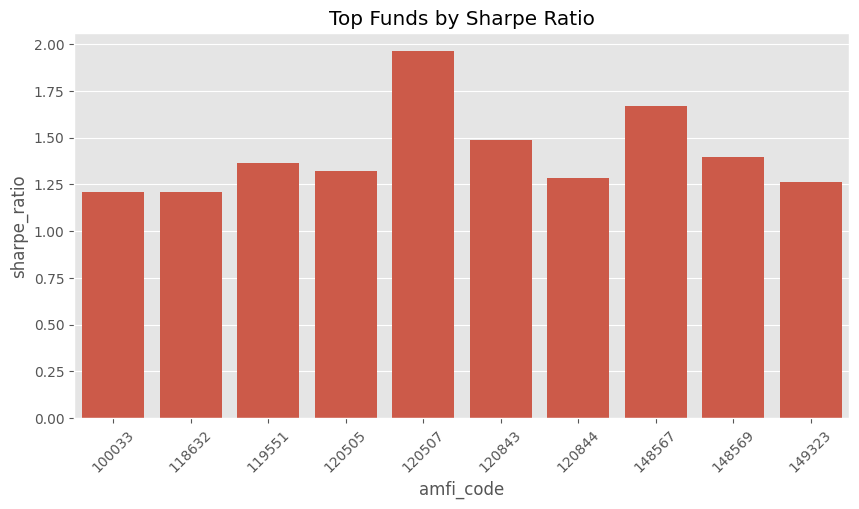

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title(
    "Top Funds by Sharpe Ratio"
)

plt.xticks(rotation=45)

plt.show()

In [17]:
top_cagr = (
    metrics_df
    .sort_values(
        "cagr",
        ascending=False
    )
    .head(10)
)

top_cagr

,amfi_code,cagr,volatility,sharpe_ratio,max_drawdown,sortino_ratio
25,120505,31.481115,19.290949,1.320884,-18.188514,2.271450
21,119598,31.095664,25.140579,0.998213,-28.706006,1.769077
39,149324,30.965766,24.840205,1.005055,-31.171900,1.714032
36,148569,30.643215,17.674007,1.394320,-16.396743,2.424011
34,148567,29.711990,14.193707,1.670599,-11.265729,2.751832
30,120843,29.648348,15.886987,1.488536,-12.973968,2.693240
2,100033,28.899384,18.936711,1.209259,-16.217209,2.022400
38,149323,28.381646,17.746159,1.261211,-17.248106,2.088907
16,119094,27.075969,19.407117,1.085992,-20.960884,1.853589
19,119551,24.772562,13.741434,1.366128,-15.012385,2.419896


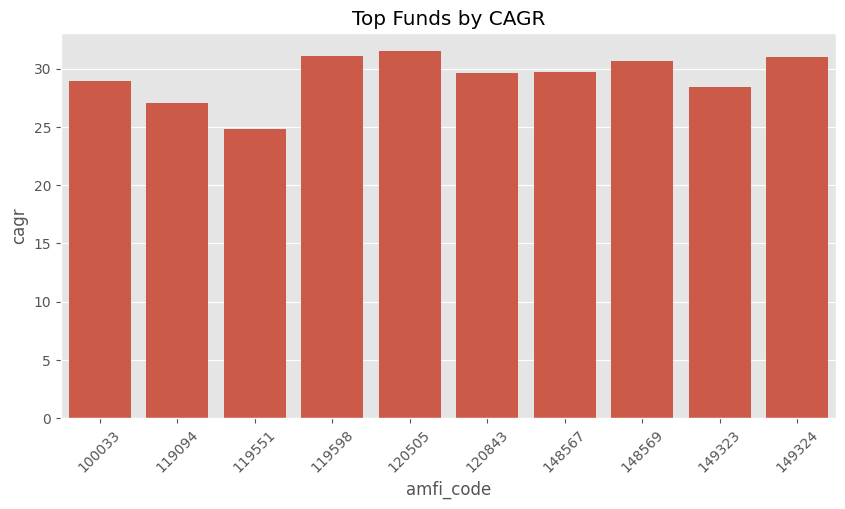

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_cagr,
    x="amfi_code",
    y="cagr"
)

plt.title(
    "Top Funds by CAGR"
)

plt.xticks(rotation=45)

plt.show()

## Value at Risk (95%)

In [19]:
def calculate_var(
    returns,
    confidence_level=0.95
):

    return np.percentile(
        returns,
        (1-confidence_level)*100
    ) * 100

In [20]:
metrics_df["var_95"] = np.nan

for i, amfi_code in enumerate(
    metrics_df["amfi_code"]
):

    returns = nav_history[
        nav_history["amfi_code"] == amfi_code
    ]["daily_return"].dropna()

    metrics_df.loc[
        i,
        "var_95"
    ] = calculate_var(returns)

In [21]:
metrics_df.sort_values(
    "var_95"
).head(10)

,amfi_code,cagr,volatility,sharpe_ratio,max_drawdown,sortino_ratio,var_95
22,119599,1.980032,24.950125,-0.161120,-52.574221,-0.265931,-2.685944
17,119095,1.466505,25.066580,-0.180858,-51.677754,-0.305151,-2.618842
4,101207,7.643258,25.797322,0.063699,-35.446916,0.108335,-2.602125
11,118634,15.741940,25.241521,0.385949,-23.344886,0.642065,-2.543811
21,119598,31.095664,25.140579,0.998213,-28.706006,1.769077,-2.450705
39,149324,30.965766,24.840205,1.005055,-31.171900,1.714032,-2.348307
7,102886,1.129460,18.134576,-0.268578,-28.001124,-0.453070,-1.922028
2,100033,28.899384,18.936711,1.209259,-16.217209,2.022400,-1.903354
25,120505,31.481115,19.290949,1.320884,-18.188514,2.271450,-1.889179
16,119094,27.075969,19.407117,1.085992,-20.960884,1.853589,-1.848028


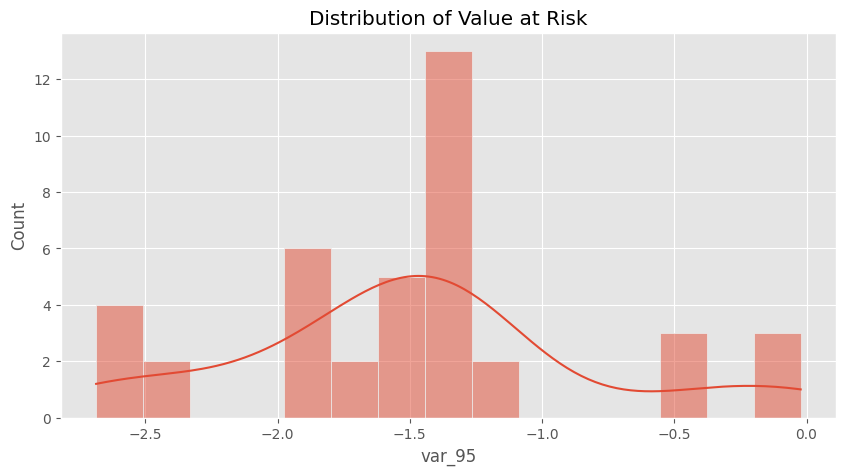

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    metrics_df["var_95"],
    bins=15,
    kde=True
)

plt.title(
    "Distribution of Value at Risk"
)

plt.show()

In [23]:
import os

os.makedirs(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\processed",
    exist_ok=True
)

In [24]:
metrics_df.to_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\processed\performance_metrics.csv",
    index=False
)

print("Metrics exported successfully")

Metrics exported successfully


In [25]:
metrics_df.head()

,amfi_code,cagr,volatility,sharpe_ratio,max_drawdown,sortino_ratio,var_95
0,100016,2.541248,14.548135,-0.237745,-24.734441,-0.414158,-1.436364
1,100025,4.294835,3.905246,-0.436634,-4.308264,-0.725155,-0.379325
2,100033,28.899384,18.936711,1.209259,-16.217209,2.022400,-1.903354
3,101206,22.604787,14.568213,1.139796,-11.291596,1.996795,-1.328166
4,101207,7.643258,25.797322,0.063699,-35.446916,0.108335,-2.602125


In [26]:
benchmark["index_name"].value_counts()

index_name
BSE_SMALLCAP       1150
CRISIL_GILT        1150
CRISIL_LIQUID      1150
NIFTY100           1150
NIFTY50            1150
NIFTY500           1150
NIFTY_MIDCAP150    1150
Name: count, dtype: int64

In [27]:
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [28]:
performance[["scheme_name","alpha","beta"]].head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [29]:
# ============================================================
# Add Scheme Names to Performance Metrics
# ============================================================

metrics_df = metrics_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Reorder columns for readability

metrics_df = metrics_df[
    [
        "amfi_code",
        "scheme_name",
        "cagr",
        "volatility",
        "sharpe_ratio",
        "sortino_ratio",
        "max_drawdown",
        "var_95"
    ]
]

# Save updated metrics file

metrics_df.to_csv(
    r"C:\Users\HP\Desktop\Mutual_Fund_Analytics\data\processed\performance_metrics.csv",
    index=False
)

print("Performance metrics file updated successfully.")
print()

metrics_df.head()

Performance metrics file updated successfully.



,amfi_code,scheme_name,cagr,volatility,sharpe_ratio,sortino_ratio,max_drawdown,var_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2.541248,14.548135,-0.237745,-0.414158,-24.734441,-1.436364
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.294835,3.905246,-0.436634,-0.725155,-4.308264,-0.379325
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,28.899384,18.936711,1.209259,2.022400,-16.217209,-1.903354
3,101206,ABSL Frontline Equity Fund - Regular - Growth,22.604787,14.568213,1.139796,1.996795,-11.291596,-1.328166
4,101207,ABSL Small Cap Fund - Regular - Growth,7.643258,25.797322,0.063699,0.108335,-35.446916,-2.602125


In [30]:
print(metrics_df.columns.tolist())

['amfi_code', 'scheme_name', 'cagr', 'volatility', 'sharpe_ratio', 'sortino_ratio', 'max_drawdown', 'var_95']


In [31]:
print(top_cagr.columns.tolist())

['amfi_code', 'cagr', 'volatility', 'sharpe_ratio', 'max_drawdown', 'sortino_ratio']


<Axes: xlabel='scheme_name', ylabel='cagr'>

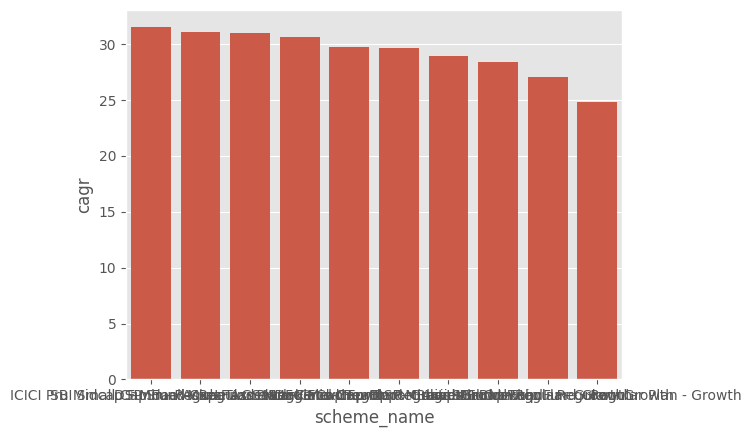

In [32]:
top_cagr = metrics_df.nlargest(10, "cagr")

sns.barplot(
    data=top_cagr,
    x="scheme_name",
    y="cagr"
)

In [33]:
metrics_df.columns

Index(['amfi_code', 'scheme_name', 'cagr', 'volatility', 'sharpe_ratio',
       'sortino_ratio', 'max_drawdown', 'var_95'],
      dtype='object')

In [34]:
top_cagr = metrics_df.nlargest(10, "cagr")

top_cagr[["scheme_name", "cagr"]].head()

,scheme_name,cagr
25,ICICI Pru Midcap Fund - Regular - Growth,31.481115
21,SBI Small Cap Fund - Regular Plan - Growth,31.095664
39,DSP Small Cap Fund - Regular - Growth,30.965766
36,Mirae Asset Tax Saver Fund - Regular - Growth,30.643215
34,Mirae Asset Large Cap Fund - Regular - Growth,29.711990


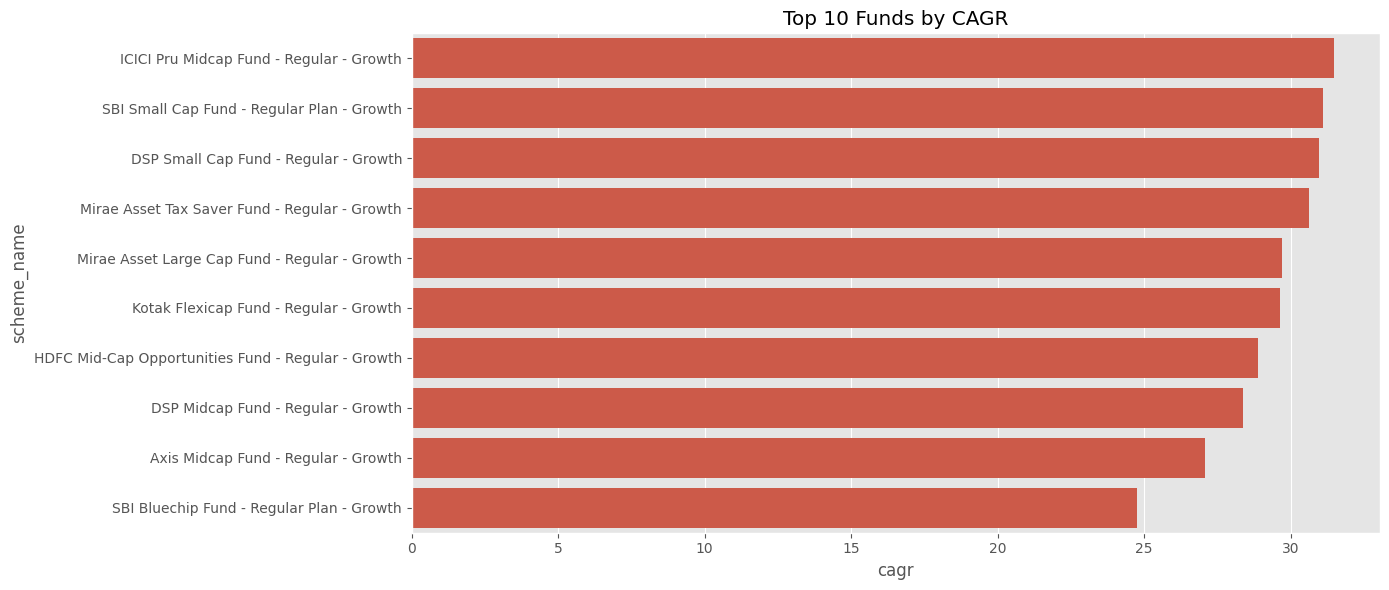

In [35]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_cagr,
    y="scheme_name",
    x="cagr"
)

plt.title("Top 10 Funds by CAGR")
plt.tight_layout()
plt.show()